In [1]:
import numpy as np
import matplotlib.pyplot as plt
import joblib as jl
from time import time

# Problem 1

Consider a square of area 4 ($A_{square} = 4$) inscribed with a circle of radius $r = 1$ ($A_{circle} = \pi r^2 = \pi$) as shown in the diagram. If the red dots are randomly placed in the square, what fraction will land in the circle?

*Solution:* The probability is just the ratio of the areas
$$ P = \frac{A_{circle}}{A_{square}} = \frac{\pi}{4} $$

# Problem 2
If we generate many random points, we can calculate an approximation to $\pi$ based on the fraction in question 1. In order to generate an estimate for the accuracy of our approximation, we use the following idea: We generate $N$ batches of $k$ points, and in each $i$-th batch ($0 \leq i < N$) we have a value $p_i$ related to the fraction computed in question 1. For $N$ batches, we would have $N$ values of $\pi$. Write $\bar\pi$ as our approximate value of $\pi$, calculated as
$$\bar\pi = \text{mean}(p_i) $$

We can also calculate a standard error
$$ \sigma_\pi = \frac{\text{std}(p_i)}{\sqrt{N}} $$

As you may have guessed, the key to getting a more accurate approximation is to add many, many points. With the help of parallelization, this process can be speed up if we carefully choose the right library functions to call, or multithread our code. Use one of the three combinations: 
1. C++ and OpenMP
2. Python and joblib
3. Python and vectorized NumPy

Write a program that takes in integers $N$, $k$ and $t$:
* $N$ is the number of batches,
* $k$ is the number of points per batch,
* $t$ is the number of threads of parallelization.

Make your function return the wall-clock time $T$ of computation, and the standard error $\sigma_\pi$.

In [2]:
def approx_pi_test(N, k, t):
    def approx_pi(k):
        points = np.random.rand(k, 2)*2 - 1
        cnt = 0
        for point in points:
            d = point[0]**2 + point[1]**2
            cnt += 1 if d <= 1 else 0
        return cnt/k * 4
    
    t0 = time()
    ps = jl.Parallel(n_jobs = t)(jl.delayed(approx_pi)(k) for i in range(N))
    t1 = time()
    
    return t1 - t0, np.std(ps)/np.sqrt(N)

# Problem 3

Generate $T$ and $\sigma_\pi$ for $N \in \{10^2, 10^3, 10^4\}, k \in \{10^2, 10^3, 10^4\}, t \in \{1, 2, 3, 4\}$.
1. How does $\sigma_\pi$ scale on the parameters $N, k, t$?
2. For constant $n_{pts} = Nk = 10^6$, how does $T$ scale with $k$ and with $N$?
3. Given the results above, for what types of values of $N$ and $k$ is multithreading most appropriate?


a=0.157	 b=-0.495


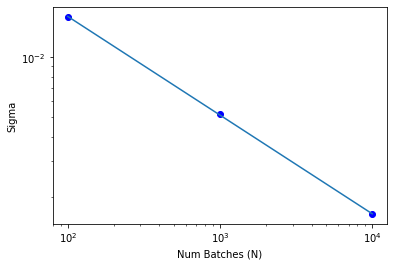


a=0.0578	 b=-0.516


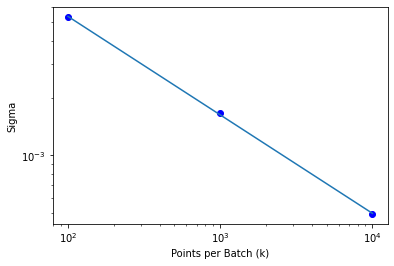


a=0.00515	 b=-0.000685


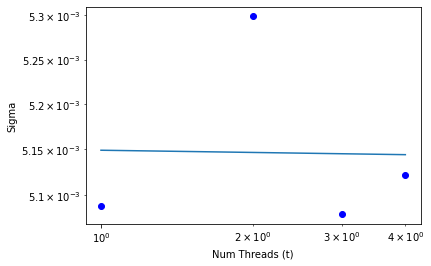

In [3]:
def fit_loglog(xs, ys, x_lab="", y_lab=""):
    A = np.asmatrix([[np.log(x), 1] for x in xs])
    b, a = np.linalg.lstsq(A, np.log(ys), rcond=None)[0]
    a = np.exp(a)
    fit = [a*x**b for x in xs]
    print(f"\na={a:.3}\t b={b:.3}")

    plt.loglog(xs, ys, 'bo')
    plt.loglog(xs, fit)
    plt.xlabel(x_lab)
    plt.ylabel(y_lab)
    plt.show()
    
Ns = [100, 1000, 10000]
ks = Ns
ts = [1, 2, 3, 4]

sigmas = []
for N in Ns:
    (T, sigma) = approx_pi_test(N, ks[0], ts[-1])
    sigmas.append(sigma)
    
fit_loglog(Ns, sigmas, "Num Batches (N)", "Sigma")

sigmas = []
for k in ks:
    (T, sigma) = approx_pi_test(Ns[1], k, ts[-1])
    sigmas.append(sigma)
    
fit_loglog(ks, sigmas, "Points per Batch (k)", "Sigma")

sigmas = []
for t in ts:
    (T, sigma) = approx_pi_test(Ns[1], ks[0], t)
    sigmas.append(sigma)
    
fit_loglog(ts, sigmas, "Num Threads (t)", "Sigma")

1) We see that $\sigma_\pi = O(N^{-0.5})$, $\sigma_\pi = O(k^{-0.5})$, and $\sigma_\pi$ is more or less independent of $t$.


a=0.291	 b=0.0318


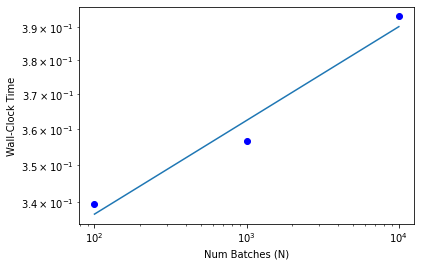


a=0.452	 b=-0.0318


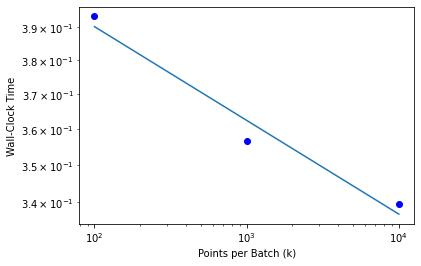

In [4]:
Ts = []
ks = []
for N in Ns:
    k = int(1e6)//N
    (T, sigma) = approx_pi_test(N, k, ts[-1])
    Ts.append(T)
    ks.append(k)
    
fit_loglog(Ns, Ts, "Num Batches (N)", "Wall-Clock Time")
fit_loglog(ks, Ts, "Points per Batch (k)", "Wall-Clock Time")

2) We see that clock time increases with the number of batches and conversely decreases as each batch contains more points

3) Small $N$ and large $K$